Use Keras's data augmentation layers for data augmentation

# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-533978c2-1516-3b71-1302-d3af1c1f6a81)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA A100-SXM4-40GB


In [3]:
# Set fixed seeding values for reproducability during experiments
# Skip this cell if random initialization (with varied results) is needed

# https://keras.io/examples/keras_recipes/reproducibility_recipes/
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
#keras.utils.set_random_seed(1234)

# 2. Prepare the MNIST dataset

In [4]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Inspect the dataset
print( f"x_train: type={type(x_train)} , dtype={x_train.dtype} , shape={x_train.shape} , min={x_train.min(axis=None)} , max={x_train.max(axis=None)}" )
print( f"y_train: type={type(y_train)} , dtype={y_train.dtype} , shape={y_train.shape} , min={min(y_train)} , max={max(y_train)} " )
print( f"x_test: type={type(x_test)} , dtype={x_test.dtype} , shape={x_test.shape} , min={x_test.min(axis=None)} , max={x_test.max(axis=None)}" )
print( f"y_test: type={type(y_test)} , dtype={y_test.dtype} , shape={y_test.shape} , min={min(y_test)} , max={max(y_test)}" )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(60000, 28, 28) , min=0 , max=255
y_train: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(60000,) , min=0 , max=9 
x_test: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(10000, 28, 28) , min=0 , max=255
y_test: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(10000,) , min=0 , max=9


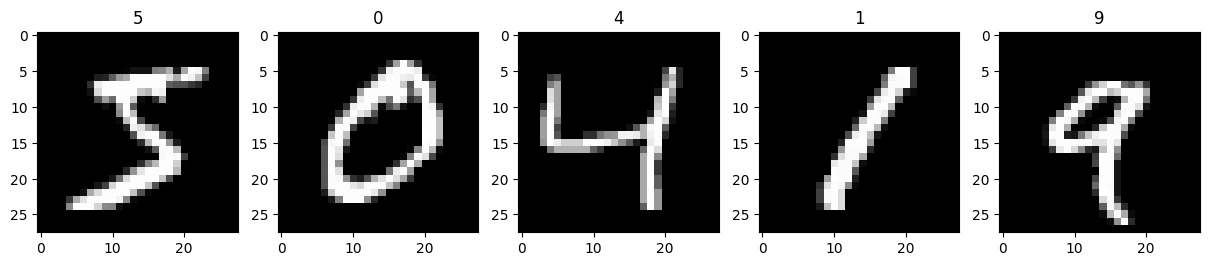

In [5]:
# Visualize the first five images in x_train
plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(150 + 1 + i).set_title( y_train[i] )
    plt.imshow( x_train[i] , cmap=plt.get_cmap('gray'))
plt.show()

In [6]:
# Convert each pixel from unsigned int 8-bit (0-255) data type to 32-bit floating point data type
x_train = x_train.astype( np.float32 )
x_test = x_test.astype( np.float32 )

# Pixel scaling from 0-255 to 0.0-1.0
x_train /= 255
x_test /= 255

print( f"x_train: type={type(x_train)} , dtype={x_train.dtype} , shape={x_train.shape} , min={x_train.min(axis=None)} , max={x_train.max(axis=None)}" )
print( f"x_test: type={type(x_test)} , dtype={x_test.dtype} , shape={x_test.shape} , min={x_test.min(axis=None)} , max={x_test.max(axis=None)}" )

x_train: type=<class 'numpy.ndarray'> , dtype=float32 , shape=(60000, 28, 28) , min=0.0 , max=1.0
x_test: type=<class 'numpy.ndarray'> , dtype=float32 , shape=(10000, 28, 28) , min=0.0 , max=1.0


In [7]:
# Conv2D layer expects an input shape of (batch_size, n_row, n_col, n_channel )
x_train = np.reshape( x_train, (-1,28,28,1) )
x_test = np.reshape( x_test, (-1,28,28,1) )

print( f"x_train.shape={x_train.shape} , x_train.dtype={x_train.dtype} , min(x_train)={np.min(x_train)} , max(x_train)={np.max(x_train)}" )
print( f"x_test.shape={x_test.shape} , x_test.dtype={x_test.dtype} , min(x_test)={np.min(x_test)} , max(x_test)={np.max(x_test)}" )

x_train.shape=(60000, 28, 28, 1) , x_train.dtype=float32 , min(x_train)=0.0 , max(x_train)=1.0
x_test.shape=(10000, 28, 28, 1) , x_test.dtype=float32 , min(x_test)=0.0 , max(x_test)=1.0


# 3. Playing with Keras's augmentation layers

Test using the augmentation model on the first `n` training images

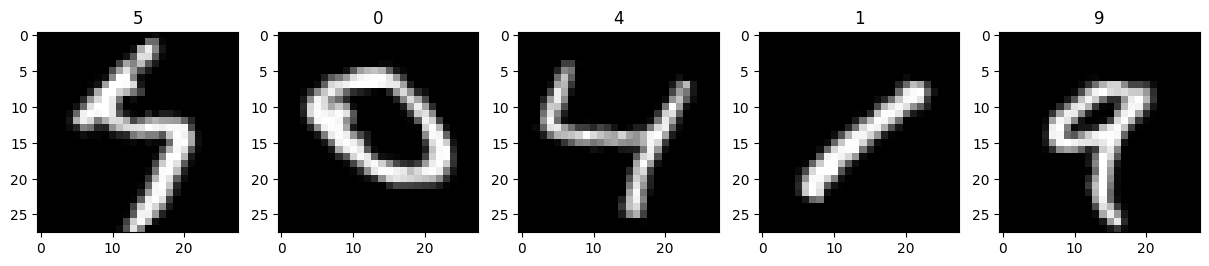

In [8]:
# RandomRotation
n = 5
x_aug = keras.layers.RandomRotation(factor=(-0.2, 0.3))( x_train[:n] )
x_aug = x_aug.cpu().numpy()

plt.figure(figsize=(15,5))
for i in range(n):
  plt.subplot(150 + 1 + i).set_title( y_train[i] )
  plt.imshow( x_aug[i].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

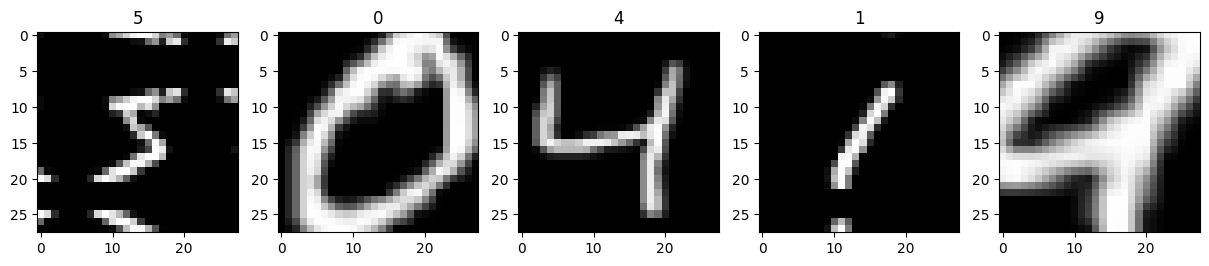

In [9]:
# RandomZoom
n = 5
x_aug = keras.layers.RandomZoom(height_factor=(-0.7, 0.7))( x_train[:n] )
x_aug = x_aug.cpu().numpy()

plt.figure(figsize=(15,5))
for i in range(n):
  plt.subplot(150 + 1 + i).set_title( y_train[i] )
  plt.imshow( x_aug[i].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

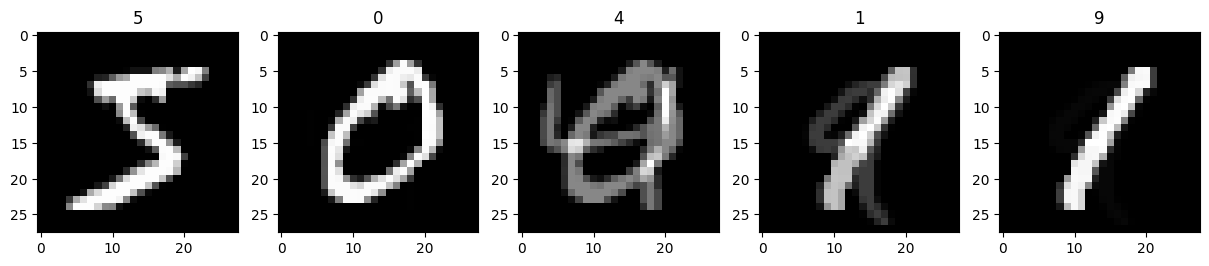

In [10]:
# MixUp: Augmentation for object detection
# arXiv 2019: https://arxiv.org/abs/1902.04103
n = 5
x_aug = keras.layers.MixUp()( x_train[:n] )
x_aug = x_aug.cpu().numpy()

plt.figure(figsize=(15,5))
for i in range(n):
  plt.subplot(150 + 1 + i).set_title( y_train[i] )
  plt.imshow( x_aug[i].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

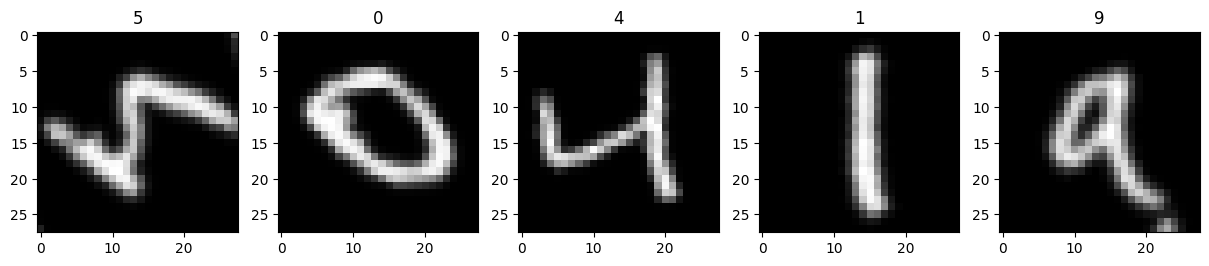

In [11]:
# RandAugment: An all-in-one image augmentation layer with a reduced search space
# NIPS 2020: https://arxiv.org/abs/1909.13719
n = 5
x_aug = keras.layers.RandAugment()( x_train[:n] )
x_aug = x_aug.cpu().numpy()

plt.figure(figsize=(15,5))
for i in range(n):
  plt.subplot(150 + 1 + i).set_title( y_train[i] )
  plt.imshow( x_aug[i].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

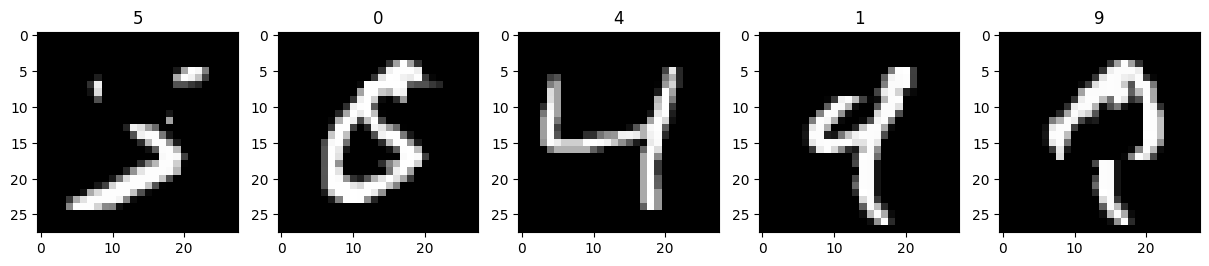

In [12]:
# CutMix: Patches are cut and pasted among training image
# ICCV 2019: https://arxiv.org/abs/1905.04899
n = 5
x_aug = keras.layers.CutMix()( x_train[:n] )  # This line causes an error from time to time
x_aug = x_aug.cpu().numpy()

plt.figure(figsize=(15,5))
for i in range(n):
  plt.subplot(150 + 1 + i).set_title( y_train[i] )
  plt.imshow( x_aug[i].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/backend/torch/numpy.py:604: UserWarning: Tensor.T is deprecated on 0-D tensors. This function is the identity in these cases. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4428.)
  return cast(torch.count_nonzero(x, dim=axis).T, "int32")


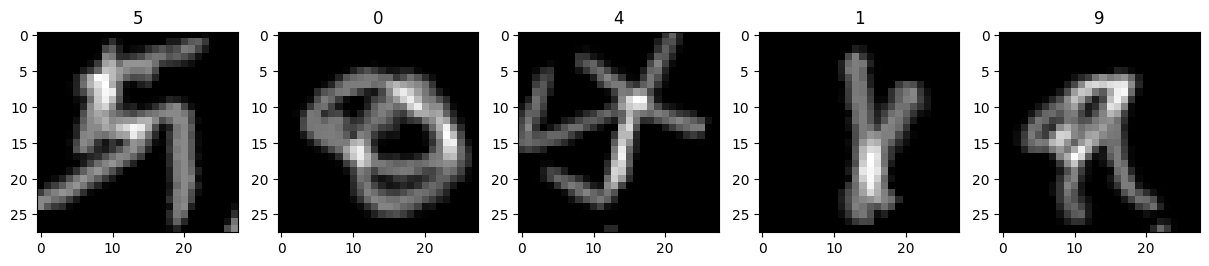

In [13]:
# AugMix: Mix many augmentations w/o degrading or drifting off the data manifold
# ICLR 2020: https://arxiv.org/abs/1912.02781
n = 5
x_aug = keras.layers.AugMix()( x_train[:n] )
x_aug = x_aug.cpu().numpy()

plt.figure(figsize=(15,5))
for i in range(n):
  plt.subplot(150 + 1 + i).set_title( y_train[i] )
  plt.imshow( x_aug[i].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

# 4. Create the network architecture with data augmentation layers


## 4.1 Create a pipeline layer containing augmentation layers

To pack many augmentation layers together in one variable, there are two alternatives:
1. Use the new `keras.layers.Pipeline()` to create <u>a new layer</u> packed with many augmentation layers inside
2. Simply create a Keras model and add all augmentation layers inside

Using Keras with PyTorch backend, as of SEP2025:
- ⚠️ Using `keras.layers.Pipeline()`, make the network creation cell (Section 4.2) to be noticably slow (~ 30 seconds). Also, the official documentation still mentioned only about how to use `Pipeline` with `tf.data.Dataset`, nothing about PyTorch was written.

In [14]:
# Alternative 1
dataaug = keras.layers.Pipeline(
            [ keras.layers.RandomFlip(mode='horizontal_and_vertical', name='rand_flip'),
              keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2, fill_mode='constant', name='rand_trans'),
              keras.layers.RandomRotation(factor=0.2, fill_mode='constant', name='rand_rot')
            ],
            name='imageaugment'
          )

In [ ]:
# Alternative 2
dataaug = keras.models.Sequential(
            [ keras.layers.RandomFlip(mode='horizontal_and_vertical', name='rand_flip'),
              keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2, fill_mode='constant', name='rand_trans'),
              keras.layers.RandomRotation(factor=0.2, fill_mode='constant', name='rand_rot')
            ],
            name='imageaugment'
          )

Repeatedly run the below cell to see how the displayed images keep changing due to random augmentation.

> Data augmentation layer is <u>**inactive at test time**</u> so input images will only be augmented during calls to `Model.fit` (not `Model.evaluate` or `Model.predict`)

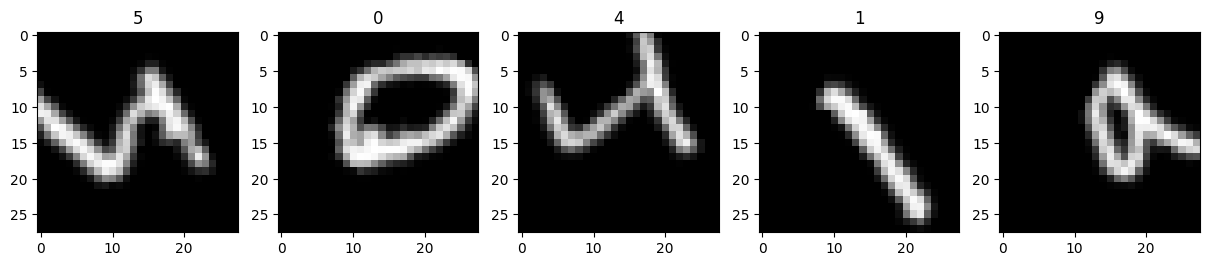

In [16]:
# Test using the augmentation model on the first five training images
n = 5
x_aug = dataaug( x_train[:n] ).cpu().numpy()

plt.figure(figsize=(15,5))
for i in range(n):
  plt.subplot(150 + 1 + i).set_title( y_train[i] )
  plt.imshow( x_aug[i].squeeze(), cmap=plt.get_cmap('gray'))
plt.show()

## 4.2 Create the main network

In [17]:
model = keras.models.Sequential()

# Input layer
model.add( keras.Input( (28,28,1), name='input' ) )

# Data augmentation
model.add( dataaug )

# Feature extractor
model.add( keras.layers.Conv2D( filters=32, kernel_size=(3,3), strides=(1,1), padding="same", activation='relu', name='conv1' ) )
model.add( keras.layers.Conv2D( filters=64, kernel_size=(3,3), strides=(1,1), padding="same", activation='relu', name='conv2' ) )
model.add( keras.layers.Conv2D( filters=32, kernel_size=(3,3), strides=(1,1), padding="same", activation='relu', name='conv3' ) )
model.add( keras.layers.MaxPooling2D(pool_size=(2,2), name='maxpool1') )

# Convert 2D feature maps to a 1D vector
model.add( keras.layers.Flatten() )

# Classifier
model.add( keras.layers.Dense( 32, activation='relu', name='dense1' ) )
model.add( keras.layers.Dense( 10, activation='softmax', name='output' ) )

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imageaugment (Pipeline)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling2D)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,346 (931.04 KB)

 Trainable params: 238,346 (931.04 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Compile and train the model

In [18]:
# Compile with default values for both optimizer and loss
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'] )

Each preprocessing layer has its own behavior regarding the validation data.
- Numerical feature preprocessing layers:
  - `Normalization`: It is applied even during inference mode, meaning that it is applied to the validation data as well.
- Image preprocessing layers (e.g., `Resizing`, `Rescaling`, `CenterCrop`):
  - They are applied even during inference mode, meaning that they are applied to the validation data as well.
- Image augmentation layers:
  - `RandomCrop`: At inference time, and during training if an input image is smaller than the target size, the input will be resized and cropped so as to return the largest possible window in the image that matches the target aspect ratio.
  - `RandomFlip`, `RandomTranslation`, `RandomRotation`, `RandomZoom`, `RandomContrast`, `RandomBrightness`, `MixUp`, `RandAugment`: They are applied during training only, meaning that <u>they are not applied to the validation data</u>.

In [19]:
# Train the model

'''
⚠️ Note on using Keras with the PyTorch backend (as of September 2025):
- Training with Keras image augmentation layers is very slow (about ~3 minutes per epoch on NVIDIA A100).
- Feeding data as NumPy arrays or through a PyTorch DataLoader (even with num_workers > 0) does not improve the speed.
- To speed up training:
     1. Switch to the TensorFlow backend (about ~1 minute per 20 epochs on NVIDIA A100), or
     2. Remove the Keras augmentation layers.
- It is suspected that Keras image augmentation is not yet integrated with GPU-accelerated data pipelines when using the PyTorch backend.
'''
history = model.fit( x_train, y_train,
                          validation_split=0.2,
                          batch_size=128,
                          epochs=5,
                          verbose=1,
                    )

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 179s 474ms/step - acc: 0.3119 - loss: 1.8958 - val_acc: 0.7098 - val_loss: 0.8987
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 177s 473ms/step - acc: 0.6393 - loss: 1.0781 - val_acc: 0.8288 - val_loss: 0.5649
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 178s 474ms/step - acc: 0.7381 - loss: 0.7994 - val_acc: 0.8518 - val_loss: 0.4927
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 178s 474ms/step - acc: 0.8021 - loss: 0.6154 - val_acc: 0.8628 - val_loss: 0.4260
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 177s 472ms/step - acc: 0.8309 - loss: 0.5328 - val_acc: 0.8571 - val_loss: 0.4400


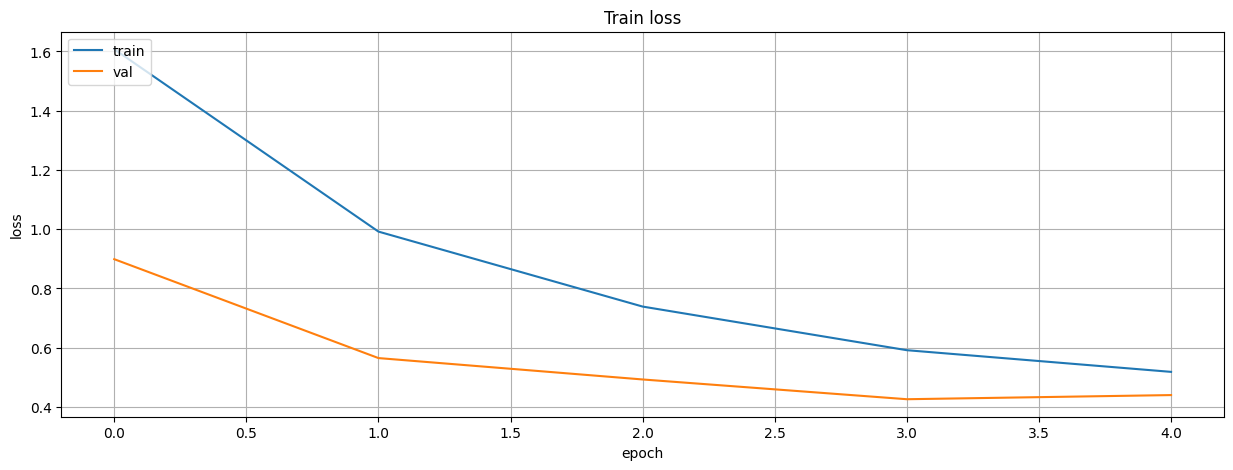

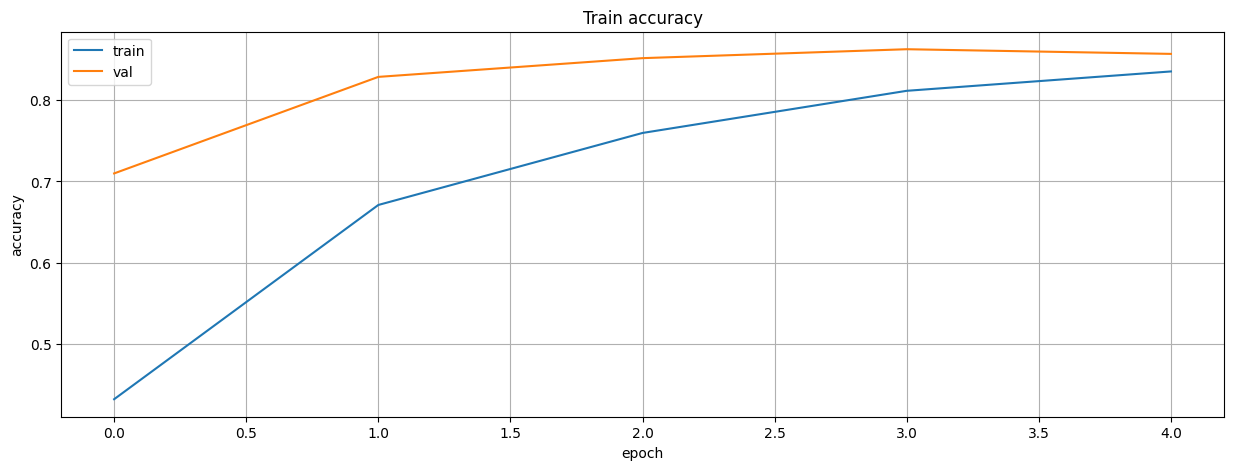

In [20]:
# Summarize history for loss
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Train loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid()
plt.show()

# Summarize history for accuracy
plt.figure(figsize=(15,5))
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Train accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid()
plt.show()

# 6. Evaluate the model on test set

In [21]:
results = model.evaluate(x_test, y_test, batch_size=128, return_dict=True)
print( results )

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.8533 - loss: 0.4460
{'acc': 0.857699990272522, 'loss': 0.43173590302467346}


# 7. Inference

In [22]:
# (Optional) Codes for coloring frames of the predicted images
plt.rcParams["axes.linewidth"] = 5

def color_frame( ax, y_true, y_pred ):
  # Green frame means correct prediction. Red frame means incorrect prediction.
  color = 'green' if (y_true == y_pred) else 'red'
  ax.spines['bottom'].set_color(color)
  ax.spines['top'].set_color(color)
  ax.spines['right'].set_color(color)
  ax.spines['left'].set_color(color)

samples.shape=(20, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


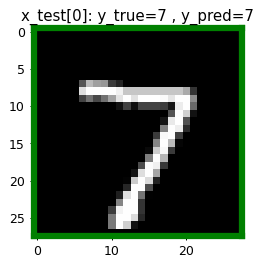

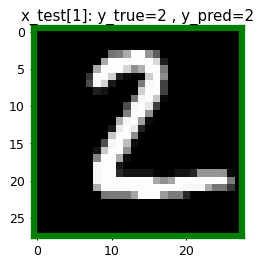

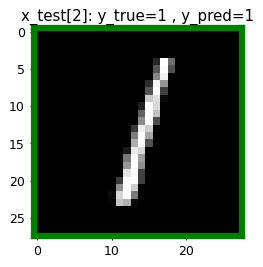

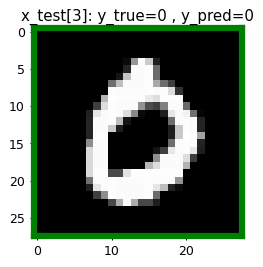

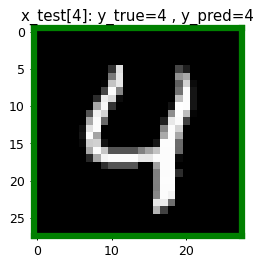

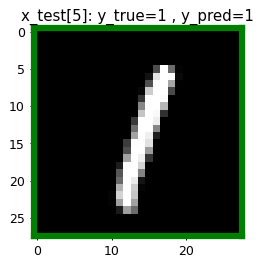

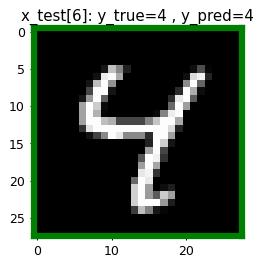

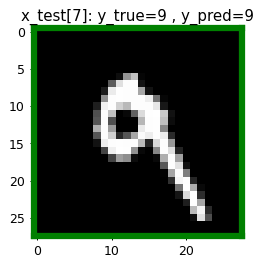

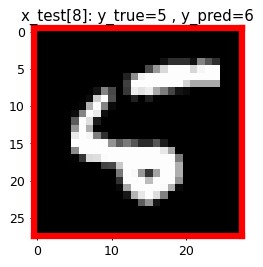

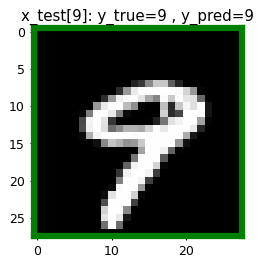

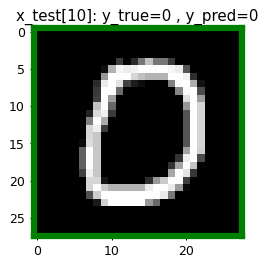

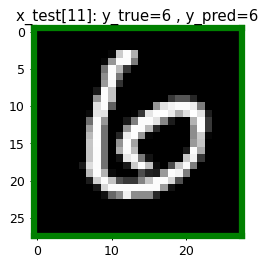

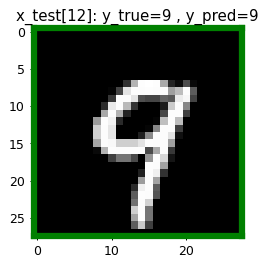

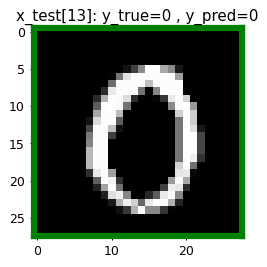

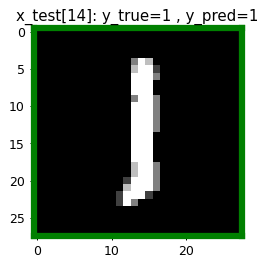

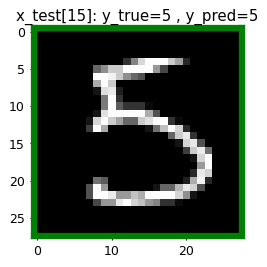

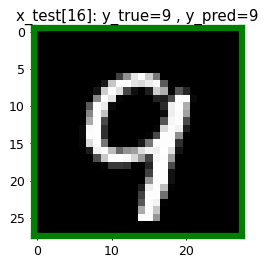

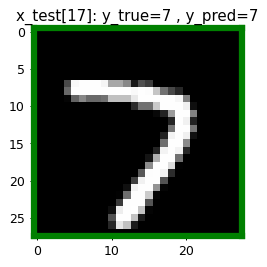

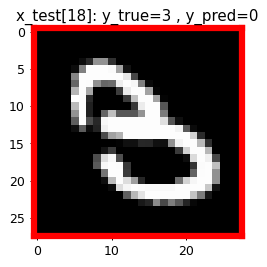

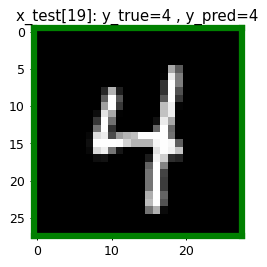

In [23]:
# Test using the model on many images

# Get a batch of samples
n = 20
samples = x_test[:n]
print(f'{samples.shape=}')

# Predict a batch of samples
y_pred = model.predict(samples)

# Interpret the results
for i in range(n):
  plt.figure(figsize=(3,3), dpi=90)
  ax = plt.gca()
  plt.imshow( samples[i].reshape(28,28), cmap='gray' )
  plt.title( f"x_test[{i}]: y_true={y_test[i]} , y_pred={np.argmax(y_pred[i])}" )
  color_frame(ax, y_test[i], np.argmax(y_pred[i]))
  plt.show()